<a href="https://colab.research.google.com/github/FShuen/Classifier/blob/master/35_normalize_autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn import svm
from sklearn import metrics
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import csv
from tensorflow import keras
import random as rd
from scipy import signal
from keras.utils import np_utils

from keras.models import Sequential
from keras.layers import LSTM,Dense,Dropout,Flatten,Conv2D,MaxPooling2D,GlobalAveragePooling2D,BatchNormalization,AveragePooling2D
from keras.callbacks import EarlyStopping
from keras.callbacks import ReduceLROnPlateau

In [2]:
excel_1 = "https://github.com/FShuen/ECE_Project_2021/raw/master/train8.xlsx"
train = pd.read_excel(excel_1,header = None, sheet_name = 0)



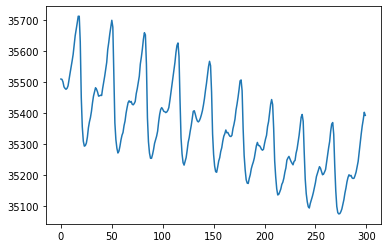

In [3]:
plt.plot(train.iloc[0:300, 0])

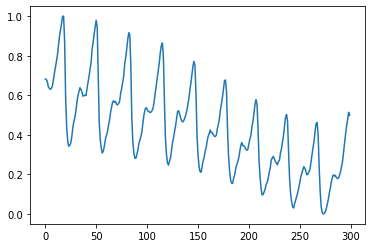

In [4]:
from sklearn import preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler

ct = ColumnTransformer(
    [(
     'normalize',
      MinMaxScaler(),
      train.columns
    )],
    remainder = 'passthrough'
)

train_scaled = ct.fit_transform(train.iloc[0:300, :])
train_scaled = pd.DataFrame(data=train_scaled)
plt.plot(train_scaled.iloc[:, 0])

In [5]:
y1 = np.swapaxes(train_scaled, 0, 1)
y1

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,...,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299
0,0.682390,0.680818,0.668239,0.643082,0.635220,0.630503,0.635220,0.647799,0.680818,0.712264,0.742138,0.773585,0.806604,0.853774,0.900943,0.932390,0.965409,1.000000,1.000000,0.871069,0.588050,0.440252,0.367925,0.342767,0.345912,0.358491,0.388365,0.435535,0.465409,0.487421,0.518868,0.561321,0.595912,0.617925,0.638365,0.630503,0.616352,0.595912,0.597484,0.600629,...,0.224843,0.262579,0.301887,0.334906,0.366352,0.418239,0.454403,0.462264,0.402516,0.243711,0.117925,0.037736,0.006289,0.000000,0.001572,0.011006,0.025157,0.048742,0.072327,0.105346,0.130503,0.161950,0.183962,0.198113,0.191824,0.194969,0.182390,0.179245,0.180818,0.194969,0.212264,0.238994,0.265723,0.312893,0.363208,0.404088,0.444969,0.476415,0.514151,0.498428
1,0.891258,0.931770,0.980810,0.982942,0.820896,0.528785,0.371002,0.289979,0.247335,0.223881,0.264392,0.283582,0.324094,0.347548,0.371002,0.392324,0.437100,0.466951,0.486141,0.492537,0.484009,0.479744,0.479744,0.475480,0.479744,0.488273,0.524520,0.547974,0.597015,0.643923,0.684435,0.714286,0.754797,0.776119,0.823028,0.872068,0.912580,0.946695,0.974414,0.965885,...,0.174840,0.204691,0.240938,0.251599,0.245203,0.240938,0.247335,0.226013,0.228145,0.240938,0.251599,0.272921,0.302772,0.349680,0.362473,0.388060,0.420043,0.462687,0.479744,0.513859,0.558635,0.592751,0.616205,0.609808,0.509595,0.285714,0.140725,0.061834,0.006397,0.000000,0.006397,0.038380,0.059701,0.093817,0.093817,0.125800,0.155650,0.181237,0.202559,0.202559
2,0.467593,0.502315,0.516204,0.532407,0.555556,0.571759,0.606481,0.631944,0.641204,0.594907,0.432870,0.240741,0.131944,0.050926,0.025463,0.018519,0.016204,0.039352,0.067130,0.076389,0.115741,0.131944,0.159722,0.192130,0.224537,0.243056,0.240741,0.226852,0.215278,0.217593,0.236111,0.250000,0.261574,0.289352,0.331019,0.358796,0.381944,0.416667,0.465278,0.497685,...,0.141204,0.094907,0.083333,0.081019,0.125000,0.171296,0.206019,0.217593,0.254630,0.293981,0.337963,0.349537,0.351852,0.354167,0.344907,0.342593,0.342593,0.342593,0.358796,0.393519,0.425926,0.479167,0.511574,0.562500,0.604167,0.666667,0.719907,0.775463,0.826389,0.861111,0.840278,0.666667,0.340278,0.164352,0.071759,0.018519,0.000000,0.020833,0.048611,0.076389
3,0.137484,0.137484,0.145266,0.163424,0.186770,0.220493,0.247730,0.278859,0.311284,0.352789,0.382620,0.402075,0.439689,0.464332,0.498054,0.525292,0.553826,0.566796,0.543450,0.424125,0.259403,0.106355,0.028534,0.006485,0.000000,0.025940,0.042802,0.073930,0.102464,0.138781,0.182879,0.225681,0.250324,0.265888,0.277562,0.267185,0.265888,0.263294,0.263294,0.287938,...,0.582361,0.594034,0.595331,0.608301,0.629053,0.666667,0.691310,0.723735,0.766537,0.787289,0.811933,0.836576,0.863813,0.884565,0.916991,0.940337,0.958495,0.967575,0.927367,0.770428,0.592737,0.437095,0.365759,0.341115,0.337224,0.347601,0.364462,0.392996,0.428016,0.465629,0.499351,0.535668,0.564202,0.575875,0.584955,0.582361,0.571984,0.568093,0.577173,0.594034
4,0.000000,0.028947,0.057895,0.084211,0.121053,0.136842,0.163158,0.202632,0.221053,0.263158,0.268421,0.268421,0.252632,0.247368,0.247368,0.265789,0.292105,0.305263,0.373684,0.426316,0.465789,0.497368,0.552632,0.589474,0.618421,0.652632,0.702632,0.742105,0.789474,0.844737,0.847368,0.744737,0.452632,0.223684,0.100000,0.039474,0.002632,0.018421,0.050000,0.110526,...,0.510526,0.523684,0.531579,0.542105,0.581579,0.613158,0.642105,0.678947,0.713158,0.765789,0.813158,0.857895,0.897368,0.950000,1.000000,0.997368,0.886842,0.607895,0.431579,0.342105,0.286842,0.268421,0.276316,0.323684,0.347368,0.384211,0.394737,0.405263,0.428947,0.471053,0.497368,0.539474,0.547368,0.550000,0.531579,0.513158,0.542105,0.560526,0.578947,0.607895
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...

(1374, 300)

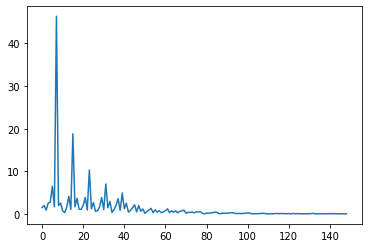

In [6]:
b, a = signal.butter(8, 0.02, 'highpass')   #配置濾波器 8 表示濾波器的階數
y1 = signal.filtfilt(b, a, y1)

y1_fft = np.abs(np.fft.rfft(y1))

plt.plot(y1_fft[324, 1:150])
y1.shape

In [7]:
num_1 = train.shape[1]

size = 200
cut = 20
size_2 = size - cut * 2

In [8]:
from matplotlib.backends.backend_agg import FigureCanvasAgg
from matplotlib.figure import Figure

fig = Figure(figsize=(3, 3), dpi = size/3)

canvas = FigureCanvasAgg(fig)

img_1 = np.zeros(shape = (num_1, size, size, 4), dtype = int)

ax = fig.add_subplot()

for i in range(0, num_1):
    ax.plot(y1_fft[i, 0:150], color = 'black')
    ax.set_xlim([0, 80])
    ax.set_ylim([0, 80])
    ax.axis("off")
    canvas.draw()
    buf = canvas.buffer_rgba()
    img_1[i] = np.asarray(buf)
    ax.clear()
    
print(img_1[0])

[[[255 255 255   0]
  [255 255 255   0]
  [255 255 255   0]
  ...
  [255 255 255   0]
  [255 255 255   0]
  [255 255 255   0]]

 [[255 255 255   0]
  [255 255 255   0]
  [255 255 255   0]
  ...
  [255 255 255   0]
  [255 255 255   0]
  [255 255 255   0]]

 [[255 255 255   0]
  [255 255 255   0]
  [255 255 255   0]
  ...
  [255 255 255   0]
  [255 255 255   0]
  [255 255 255   0]]

 ...

 [[255 255 255   0]
  [255 255 255   0]
  [255 255 255   0]
  ...
  [255 255 255   0]
  [255 255 255   0]
  [255 255 255   0]]

 [[255 255 255   0]
  [255 255 255   0]
  [255 255 255   0]
  ...
  [255 255 255   0]
  [255 255 255   0]
  [255 255 255   0]]

 [[255 255 255   0]
  [255 255 255   0]
  [255 255 255   0]
  ...
  [255 255 255   0]
  [255 255 255   0]
  [255 255 255   0]]]


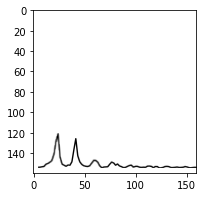

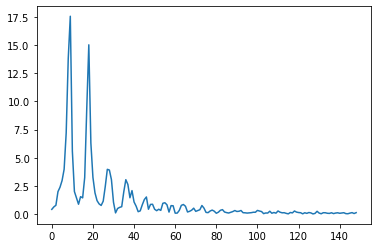

In [9]:
def plot_image(image):
    plt.clf()
    fig = plt.gcf()
    fig.set_size_inches(3, 3)
    plt.imshow(image, cmap='binary')
    plt.show()
    
plot_image(img_1[0, cut:size-cut, cut:size-cut])
plt.plot(y1_fft[0, 1:150])
plt.show()

In [10]:
def rgba(image):
    new_img = np.zeros(shape = (size_2, size_2, 1), dtype = int)
    for i in range(0, size_2):
        for j in range(0, size_2):
            if image[i + cut, j + cut, 0] < 255:
                new_img[i, j, 0] = 1
    return new_img

In [11]:
img_rgba1 = np.zeros(shape = (num_1, size_2, size_2, 1), dtype = int)
for i in range(0, num_1):
    img_rgba1[i] = rgba(img_1[i])

In [12]:
# plot_image(img_rgba1[0])

In [13]:
# plot_image(img_1[0])

In [14]:
labels_1 = np.swapaxes(train, 0, 1)[304]

labels_onehot1 = np_utils.to_categorical(labels_1)

labels_onehot1.shape

(1374, 36)

In [15]:
index = np.arange(0, num_1, dtype = int)
rd.shuffle(index)
img_rgba1 = img_rgba1[index]
labels_onehot1 = labels_onehot1[index]

In [16]:
excel_2 = "https://github.com/FShuen/ECE_Project_2021/raw/master/test8.xlsx"
test = pd.read_excel(excel_2,header = None, sheet_name = 0)
# , usecols = 'A:HS'
test

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,...,660,661,662,663,664,665,666,667,668,669,670,671,672,673,674,675,676,677,678,679,680,681,682,683,684,685,686,687,688,689,690,691,692,693,694,695,696,697,698,699
0,35115.0,34856.0,35398.0,34462.0,35153.0,35457.0,33382.0,34538.0,35012.0,34985.0,33928.0,33260.0,35078.0,34978.0,34924.0,33848.0,34242.0,34512.0,34729.0,34400.0,35169.0,35085.0,34722.0,34737.0,34473.0,34445.0,34457.0,34573.0,34412.0,34788.0,34704.0,33622.0,33950.0,33760.0,31521.0,31368.0,32040.0,31785.0,31647.0,31732.0,...,27844.0,27931.0,27567.0,27373.0,28051.0,27722.0,27015.0,26444.0,26364.0,26460.0,26321.0,27369.0,27146.0,27192.0,27114.0,27024.0,26828.0,27044.0,26889.0,26738.0,27413.0,27018.0,26895.0,26775.0,26906.0,29806.0,29979.0,29822.0,29828.0,29577.0,29496.0,29361.0,29285.0,29654.0,29577.0,29106.0,28819.0,29448.0,29461.0,29329.0
1,35119.0,34866.0,35413.0,34484.0,35171.0,35367.0,33246.0,34554.0,35040.0,35015.0,33944.0,33269.0,35094.0,35008.0,34898.0,33743.0,34251.0,34491.0,34751.0,34401.0,35204.0,34880.0,34761.0,34763.0,34493.0,34459.0,34488.0,34581.0,34405.0,34811.0,34722.0,33636.0,33964.0,33765.0,31552.0,31342.0,31949.0,31818.0,31673.0,31647.0,...,27845.0,27935.0,27569.0,27370.0,28054.0,27729.0,27000.0,26437.0,26375.0,26465.0,26322.0,27373.0,27149.0,27194.0,27121.0,27031.0,26831.0,27052.0,26887.0,26739.0,27420.0,27014.0,26902.0,26776.0,26913.0,29809.0,29992.0,29822.0,29836.0,29577.0,29505.0,29360.0,29283.0,29657.0,29589.0,29097.0,28819.0,29441.0,29470.0,29337.0
2,35113.0,34884.0,35415.0,34500.0,35193.0,35210.0,33025.0,34564.0,35064.0,35031.0,33955.0,33281.0,35111.0,35029.0,34892.0,33693.0,34228.0,34494.0,34771.0,34411.0,35236.0,34728.0,34790.0,34782.0,34512.0,34479.0,34527.0,34605.0,34424.0,34836.0,34751.0,33656.0,33970.0,33763.0,31578.0,31339.0,31848.0,31837.0,31696.0,31567.0,...,27849.0,27935.0,27565.0,27371.0,28056.0,27728.0,26989.0,26428.0,26382.0,26474.0,26321.0,27372.0,27152.0,27193.0,27120.0,27031.0,26835.0,27051.0,26890.0,26743.0,27424.0,27020.0,26911.0,26777.0,26918.0,29816.0,29999.0,29816.0,29833.0,29585.0,29518.0,29357.0,29278.0,29666.0,29594.0,29098.0,28813.0,29451.0,29480.0,29338.0
3,35107.0,34895.0,35349.0,34506.0,35200.0,35129.0,32896.0,34575.0,35090.0,35051.0,33972.0,33301.0,35131.0,35039.0,34900.0,33676.0,34080.0,34510.0,34795.0,34429.0,35259.0,34672.0,34797.0,34808.0,34543.0,34501.0,34571.0,34615.0,34458.0,34859.0,34771.0,33677.0,33976.0,33766.0,31596.0,31340.0,31768.0,31867.0,31727.0,31517.0,...,27849.0,27935.0,27567.0,27366.0,28057.0,27729.0,26985.0,26424.0,26389.0,26476.0,26324.0,27369.0,27158.0,27190.0,27120.0,27034.0,26835.0,27051.0,26895.0,26750.0,27426.0,27025.0,26918.0,26787.0,26928.0,29819.0,30009.0,29821.0,29830.0,29586.0,29528.0,29361.0,29278.0,29675.0,29599.0,29113.0,28808.0,29463.0,29495.0,29346.0
4,35107.0,34913.0,35210.0,34443.0,35221.0,35082.0,32844.0,34581.0,35103.0,35072.0,33988.0,33325.0,35160.0,35035.0,34917.0,33678.0,33890.0,34533.0,34825.0,34458.0,35278.0,34656.0,34810.0,34845.0,34565.0,34536.0,34604.0,34647.0,34489.0,34892.0,34802.0,33699.0,33976.0,33776.0,31599.0,31348.0,31710.0,31892.0,31752.0,31488.0,...,27851.0,27936.0,27566.0,27372.0,28060.0,27729.0,26984.0,26426.0,26395.0,26483.0,26329.0,27358.0,27161.0,27193.0,27118.0,27040.0,26839.0,27047.0,26900.0,26754.0,27430.0,27030.0,26919.0,26793.0,26939.0,29829.0,30020.0,29822.0,29828.0,29589.0,29540.0,29369.0,29284.0,29688.0,29609.0,29129.0,28810.0,29475.0,29505.0,29352.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...

In [17]:
num_2 = test.shape[1]
num_2

700

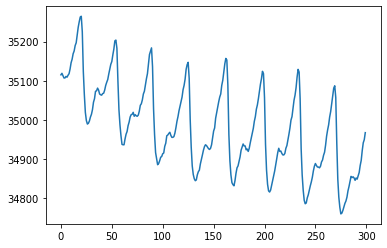

In [18]:
plt.plot(test.iloc[0:300, 0])

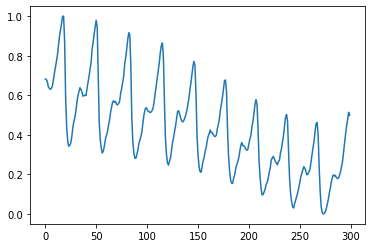

In [19]:
ct2 = ColumnTransformer(
    [(
     'normalize2',
      MinMaxScaler(),
      test.columns
    )],
    remainder = 'passthrough'
)

test_scaled = ct2.fit_transform(test.iloc[0:300, :])
test_scaled = pd.DataFrame(data=test_scaled)
plt.plot(train_scaled.iloc[:, 0])


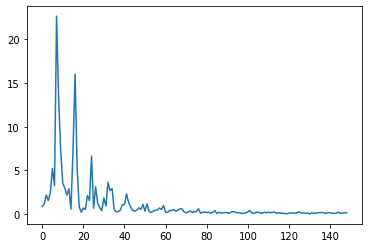

In [20]:
y2 = np.swapaxes(test_scaled, 0, 1)

y2 = signal.filtfilt(b, a, y2)

y2_fft = np.abs(np.fft.rfft(y2))  #快速傅里葉變換

plt.plot(y2_fft[0, 1:150])

In [21]:
img_2 = np.zeros(shape = (num_2, size, size, 4), dtype = int)
for i in range(0, num_2):
    ax.plot(y2_fft[i, 0:150], color = 'black')
    ax.set_xlim([0, 80])
    ax.set_ylim([0, 80])
    ax.axis("off")
    canvas.draw()
    buf = canvas.buffer_rgba()
    img_2[i] = np.asarray(buf)
    ax.clear()

In [22]:
img_rgba2 = np.zeros(shape = (num_2, size_2, size_2, 1), dtype = int)
for i in range(0, num_2):
    img_rgba2[i] = rgba(img_2[i])

In [23]:
labels_2 = np.swapaxes(test, 0, 1)[304]

labels_onehot2 = np_utils.to_categorical(labels_2)

labels_2

0       1.0
1       1.0
2       1.0
3       1.0
4       1.0
       ... 
695    35.0
696    35.0
697    35.0
698    35.0
699    35.0
Name: 304, Length: 700, dtype: float64

In [24]:
# 從這行向下執行
k_s1 = 3
k_s2 = 3
k_s3 = 3
b_s = 2
ep = 100
keras.backend.clear_session()

In [31]:
import tensorflow as tf
import keras
from keras import layers
from keras.layers import UpSampling2D

input_img = keras.Input(shape=(size_2, size_2, 1))
x = layers.Conv2D(12, (3, 3), activation='relu', padding='same')(input_img)
x = layers.AveragePooling2D((2, 2))(x)
x = layers.Dropout(0.2)(x)

x = layers.Conv2D(24, (3, 3), activation='relu', padding='same')(x)
x = layers.AveragePooling2D((2, 2))(x)
x = layers.Dropout(0.2)(x)

x = layers.Conv2D(36, (3, 3), activation='relu', padding='same')(x)
x = layers.AveragePooling2D((2, 2))(x)
x = layers.Dropout(0.2)(x)


x = layers.Conv2D(48, (3, 3), activation='relu', padding='same')(x)
x = layers.AveragePooling2D((2, 2))(x)
x = layers.Dropout(0.1)(x)

x = layers.Conv2D(96, (3, 3), activation='relu', padding='same')(x)
x = layers.AveragePooling2D((2, 2))(x)
encoded = layers.Dropout(0.1)(x)

x = layers.Conv2D(96, (3, 3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2, 2))(x)

x = layers.Conv2D(48, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)

x = layers.Conv2D(36, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)

x = layers.Conv2D(24, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)

x = layers.Conv2D(12, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder = keras.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

encoded = layers.Flatten()(encoded)
encoded = layers.Dense(128,activation='relu')(encoded)
encoded = layers.Dense(64,activation='relu')(encoded)
encoded = layers.Dense(36,activation='softmax')(encoded)

encoder = keras.Model(input_img, encoded)
opt = tf.keras.optimizers.Adam(learning_rate=0.001)
encoder.compile(loss = 'categorical_crossentropy', optimizer = opt ,metrics=['accuracy'])

In [27]:
earlystop = EarlyStopping(monitor='val_loss', patience=20, verbose=1)
learning_rate_function = ReduceLROnPlateau(monitor='val_loss',  patience=6,  verbose=1, factor=0.5,  min_lr=0.000000001)

autoencoder_history = autoencoder.fit(x = img_rgba1, y = img_rgba1, validation_split = 0.1, epochs = ep, batch_size = b_s, verbose = 2, callbacks = [earlystop, learning_rate_function])

Epoch 1/100
618/618 - 16s - loss: 0.0607 - val_loss: 0.0438 - lr: 0.0010 - 16s/epoch - 26ms/step
Epoch 2/100
618/618 - 6s - loss: 0.0404 - val_loss: 0.0367 - lr: 0.0010 - 6s/epoch - 10ms/step
Epoch 3/100
618/618 - 6s - loss: 0.0358 - val_loss: 0.0330 - lr: 0.0010 - 6s/epoch - 10ms/step
Epoch 4/100
618/618 - 6s - loss: 0.0331 - val_loss: 0.0306 - lr: 0.0010 - 6s/epoch - 10ms/step
Epoch 5/100
618/618 - 6s - loss: 0.0306 - val_loss: 0.0286 - lr: 0.0010 - 6s/epoch - 10ms/step
Epoch 6/100
618/618 - 6s - loss: 0.0288 - val_loss: 0.0267 - lr: 0.0010 - 6s/epoch - 10ms/step
Epoch 7/100
618/618 - 6s - loss: 0.0275 - val_loss: 0.0263 - lr: 0.0010 - 6s/epoch - 10ms/step
Epoch 8/100
618/618 - 6s - loss: 0.0260 - val_loss: 0.0249 - lr: 0.0010 - 6s/epoch - 10ms/step
Epoch 9/100
618/618 - 6s - loss: 0.0252 - val_loss: 0.0235 - lr: 0.0010 - 6s/epoch - 10ms/step
Epoch 10/100
618/618 - 6s - loss: 0.0244 - val_loss: 0.0229 - lr: 0.0010 - 6s/epoch - 10ms/step
Epoch 11/100
618/618 - 6s - loss: 0.0236 - val_

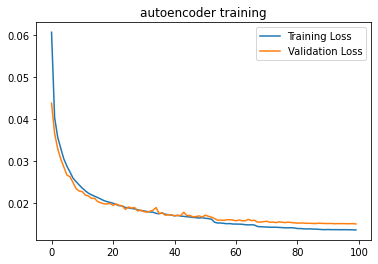

In [28]:
plt.plot(autoencoder_history.history["loss"], label="Training Loss")
plt.plot(autoencoder_history.history["val_loss"], label="Validation Loss")
plt.title('autoencoder training')
plt.legend()

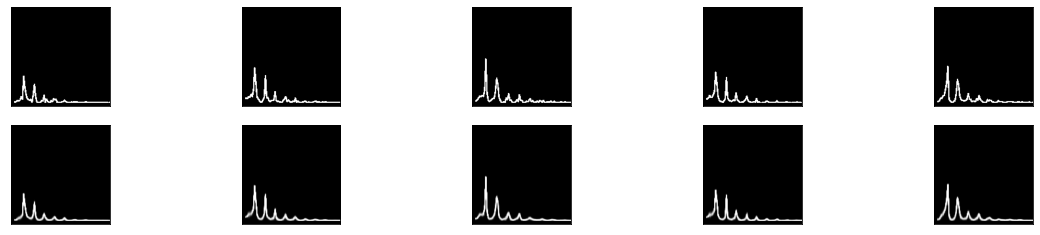

In [29]:
import matplotlib.pyplot as plt
autoencoder_pred = autoencoder.predict(img_rgba2)
plt.figure(figsize=(20, 4))
for i in range(5):
    # Display original
    ax = plt.subplot(2, 5, i + 1)
    plt.imshow(img_rgba2[i].reshape(160,160))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    # Display reconstruction
    ax = plt.subplot(2, 5, i + 1 + 5)
    plt.imshow(autoencoder_pred[i].reshape(160,160))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

<h2>--------------------Encoder Part----------------------</h2>



In [30]:
encoder_history = encoder.fit(x = img_rgba1, y = labels_onehot1, validation_split = 0.1, epochs = ep, batch_size = b_s, verbose = 2, callbacks = [learning_rate_function])

Epoch 1/100


ValueError: ignored

In [ ]:
def show_train_history(train_history, train, validation):
  plt.plot(train_history.history[train])
  plt.plot(train_history.history[validation])
  plt.title("Train History")
  plt.ylabel("train")
  plt.xlabel("Epoch")
  plt.legend(["train", "validation"], loc="center right")
  plt.show()


# show_train_history(encoder_history, 'accuracy','val_accuracy')
show_train_history(encoder_history, 'accuracy','val_accuracy')

In [ ]:
scores = encoder.evaluate(img_rgba2 ,labels_onehot2)
print(scores[1])

In [ ]:
prediction=encoder.predict(img_rgba2)
classes_x=np.argmax(prediction,axis=1)
classes_x